In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
sys.path.append('/root/capsule/code/beh_ephys_analysis')
from utils.ephys_functions import fitSpikeModelG
import platform
import os
from pathlib import Path
import shutil
from utils.beh_functions import session_dirs, get_session_tbl, makeSessionDF
from utils.photometry_utils import get_FP_data
from matplotlib import pyplot as plt
from IPython.display import display
from scipy.signal import find_peaks
from harp.clock import align_timestamps_to_anchor_points
import numpy as np
from scipy.signal import butter, filtfilt, medfilt, sosfiltfilt
from scipy.optimize import curve_fit
import json
from sklearn.linear_model import LinearRegression
from matplotlib.gridspec import GridSpec
import pickle
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time

# %matplotlib widget
import re
import random
from matplotlib.gridspec import GridSpec
from utils.photometry_combine import population_GLM, plot_tuning_curve, plot_psth, population_GLM_ani
from contextlib import redirect_stdout
%matplotlib inline

In [2]:
session_csv = '/root/capsule/code/data_management/hopkins_FP_session_assets.csv'
session_tbl = pd.read_csv(session_csv)
session_list = session_tbl['session_id'].tolist()
target_folder = '/root/capsule/results/manuscript/F_photometry'
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
save_dir = os.path.join(target_folder, 'tuning&psth')

In [3]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'choice_time'
num_bins = 6
thresh_curr = 0.5
quantiles = False
pre_time = -0.2
post_time = 2.2

params_dict = {
    'region_curr': region_curr,
    'channel_curr': channel_curr,
    'align_curr': align_curr,
    'num_bins': num_bins,
    'thresh_curr': thresh_curr,
    'quantiles': quantiles,
    'pre_time': pre_time,
    'post_time': post_time
}
print(f'Processing tuning curve for region: {region_curr}, channel: {channel_curr}, align: {align_curr}, num_bins: {num_bins}, threshold: {thresh_curr}')

results = plot_tuning_curve(
    session_list, region=region_curr, target_var = 'pe', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
)

save_dir = os.path.join(target_folder, 'tuning&psth')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
file_name = f'population_tuning_curve_pe_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(results, f)
    pickle.dump(params_dict, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
# save fig
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)

Processing tuning curve for region: PL, channel: G_tri-exp_mc, align: choice_time, num_bins: 6, threshold: 0.5


FileNotFoundError: [Errno 2] No such file or directory: '/root/capsule/data/behavior_669489_2023-06-24_14-56-01_raw_data'

In [ ]:
os.path.join(save_dir, file_name.replace('.pkl', '.pdf'))

'/root/capsule/scratch/manuscript/F_photometry/tuning&psth/population_psth_by_hit_PL_G_tri-exp_mc_goCue_start_time_numbins2_thresg0.5_quantilesFalse.pdf'

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])
/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


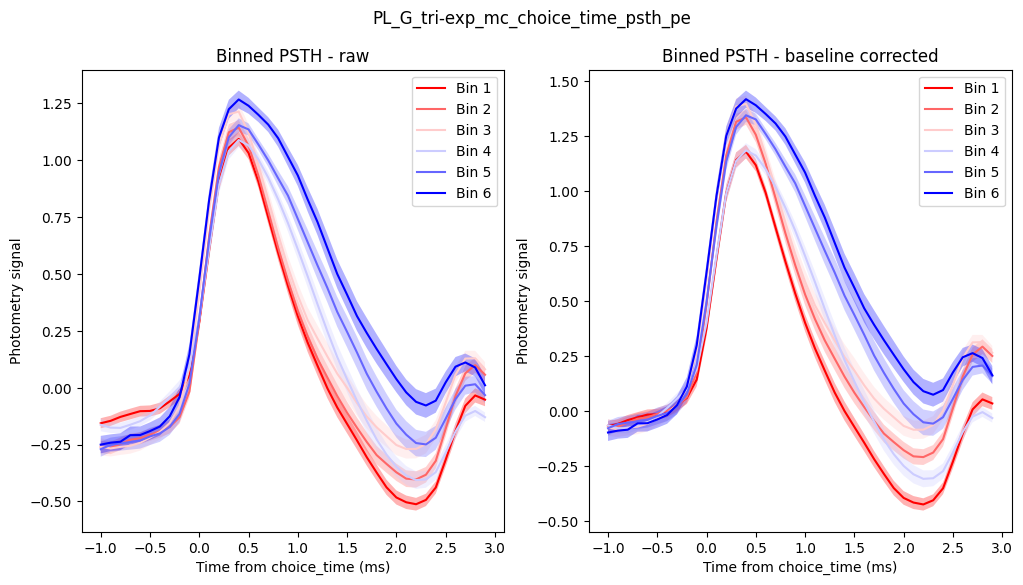

In [ ]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'choice_time'
pre_time = 1
post_time = 3
num_bins = 6
thresh_curr = 0.5
quantiles = False

params_dict = {
    'region_curr': region_curr,
    'channel_curr': channel_curr,
    'align_curr': align_curr,
    'num_bins': num_bins,
    'thresh_curr': thresh_curr,
    'quantiles': quantiles,
    'pre_time': pre_time,
    'post_time': post_time
}
results = plot_psth(
    session_list, region=region_curr, target_var = 'pe', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
);
file_name = f'population_psth_pe_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(results, f)
    pickle.dump(params_dict, f)
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])
/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/root/capsule/code/beh_ephys_analysis/utils/photometry_combine.py:606: RuntimeWarning: Mean of empty slice
  mean_binned_psth = np.nanmean(a

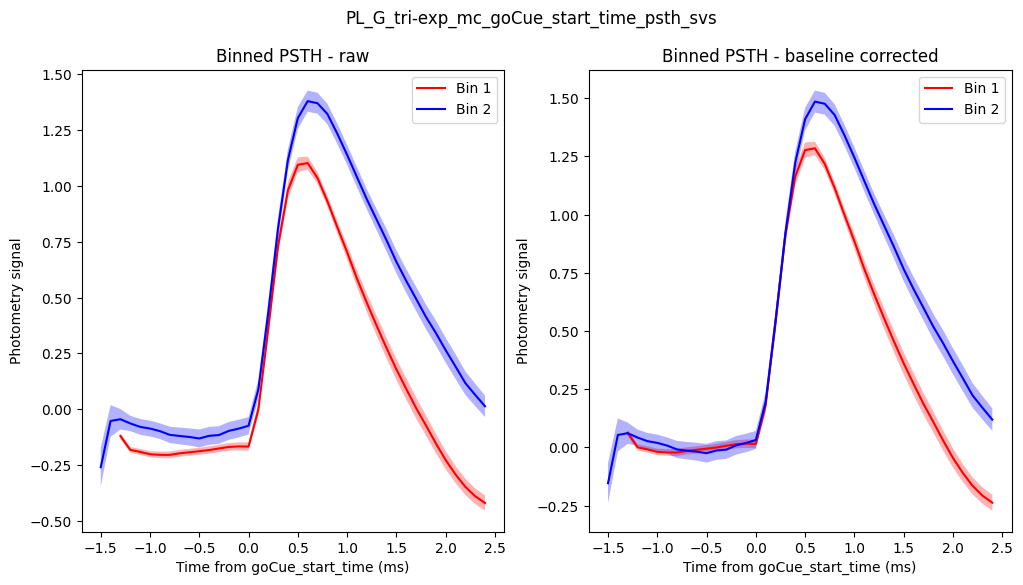

In [ ]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'goCue_start_time'
pre_time = 1.0
post_time = 2.5
num_bins = 2
thresh_curr = 0.5
quantiles = False
results = plot_psth(
    session_list, region=region_curr, target_var = 'svs', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
);
file_name = f'population_psth_by_hit_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)

In [ ]:
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'goCue_start_time'
pre_time = 3.5
post_time = 2.5
num_bins = 2
thresh_curr = 0.5
quantiles = False
results = plot_psth(
    session_list, region=region_curr, target_var = 'hit', channel= channel_curr, 
    align=align_curr, pre_time=pre_time, post_time=post_time, num_bins=num_bins, thresh=thresh_curr, quantiles=quantiles
);
file_name = f'population_psth_by_hit_{region_curr}_{channel_curr}_{align_curr}_numbins{num_bins}_thresg{thresh_curr}_quantiles{quantiles}.pkl'
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)

In [ ]:
# plot scatter and polar histogram of glm weights
save_dir = os.path.join(target_folder, 'population_GLM_results')
session_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_choice_time_win2_thresh0.5_formula_1_outcomexipsi_Qchosen_iso.pkl'
ani_file_name = 'population_GLM_animal-wise_PL_G_tri-exp_mc_choice_time_win2_thresh0.5_formula_1_outcomexipsi_Qchosen_iso.pkl'
with open(os.path.join(save_dir, session_file_name), 'rb') as f:
    params_dict = pickle.load(f)
    results = pickle.load(f)
with open(os.path.join(save_dir, ani_file_name), 'rb') as f:
    ani_params_dict = pickle.load(f)
    ani_results = pickle.load(f)
plt.close('all')

In [ ]:
time_bins = results['time_bins']
target_start = 1.0
target_start_ind = np.where(time_bins >= target_start)[0][0]
time_bins[target_start_ind]

np.float64(0.7000000000000002)

In [ ]:
ani_list = [session_dirs(session)['aniID'] for session in results['session_list']]
uni_ani = np.unique(ani_list)

Parsing session_id: behavior_669492_2023-06-24_17-28-24, aniID: 669492
Parsing session_id: behavior_669492_2023-06-26_19-14-31, aniID: 669492
Parsing session_id: behavior_669492_2023-06-29_18-28-17, aniID: 669492
Parsing session_id: behavior_669492_2023-06-30_15-51-45, aniID: 669492
Parsing session_id: behavior_669492_2023-07-01_19-25-23, aniID: 669492
Parsing session_id: behavior_669492_2023-07-02_16-02-53, aniID: 669492
Parsing session_id: behavior_669492_2023-07-03_15-55-33, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-05_18-51-39, aniID: 669492
Parsing session_id: behavior_669492_2023-07-06_16-39-19, aniID: 669492
Parsing session_id: behavior_669492_2023-07-07_17-52-04, aniID: 669492
Parsing session_id: behavior_669492_2023-07-08_19-35-55, aniID: 669492
Parsing session_id: behavior_669492_2023-07-10_17-03-12, aniID: 669492
Parsing session_id: behavior_669492_2023-07-11_19-01-10, aniID: 669492
Parsin

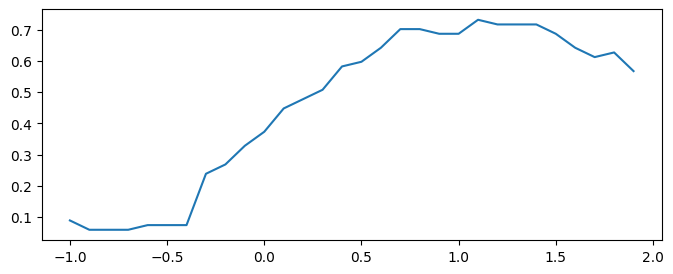

In [ ]:
fig = plt.figure(figsize=(8, 3))
regressors = list(results['regressors'])
plt.plot(time_bins, results['sig_prop_P'][:, regressors.index('outcome')] + results['sig_prop_N'][:, regressors.index('outcome')]);

Parsing session_id: behavior_669492_2023-06-24_17-28-24, aniID: 669492
Parsing session_id: behavior_669492_2023-06-26_19-14-31, aniID: 669492
Parsing session_id: behavior_669492_2023-06-29_18-28-17, aniID: 669492
Parsing session_id: behavior_669492_2023-06-30_15-51-45, aniID: 669492
Parsing session_id: behavior_669492_2023-07-01_19-25-23, aniID: 669492
Parsing session_id: behavior_669492_2023-07-02_16-02-53, aniID: 669492
Parsing session_id: behavior_669492_2023-07-03_15-55-33, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-05_18-51-39, aniID: 669492
Parsing session_id: behavior_669492_2023-07-06_16-39-19, aniID: 669492
Parsing session_id: behavior_669492_2023-07-07_17-52-04, aniID: 669492
Parsing session_id: behavior_669492_2023-07-08_19-35-55, aniID: 669492
Parsing session_id: behavior_669492_2023-07-10_17-03-12, aniID: 669492
Parsing session_id: behavior_669492_2023-07-11_19-01-10, aniID: 669492
Parsin

/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Parsing session_id: behavior_669492_2023-07-08_19-35-55, aniID: 669492
Parsing session_id: behavior_669492_2023-07-10_17-03-12, aniID: 669492
Parsing session_id: behavior_669492_2023-07-11_19-01-10, aniID: 669492
Parsing session_id: behavior_669492_2023-07-12_17-52-57, aniID: 669492
Parsing session_id: behavior_699462_2024-01-03_12-05-59, aniID: 699462
Parsing session_id: behavior_699462_2024-01-04_11-39-29, aniID: 699462
Parsing session_id: behavior_699462_2024-01-06_13-39-52, aniID: 699462
Parsing session_id: behavior_699462_2024-01-07_13-20-27, aniID: 699462
Parsing session_id: behavior_699462_2024-01-08_11-59-21, aniID: 699462
Parsing session_id: behavior_699462_2024-01-09_11-34-51, aniID: 699462
Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_699462_2024-01-12_11-40-23, aniID: 699462
Parsing session_id: behavior_699462_2024-01-13_15-11-33, aniID: 699462
Parsing session_id: behavior_699462_2024-01-14_15-41-48, aniID: 699462
Parsin

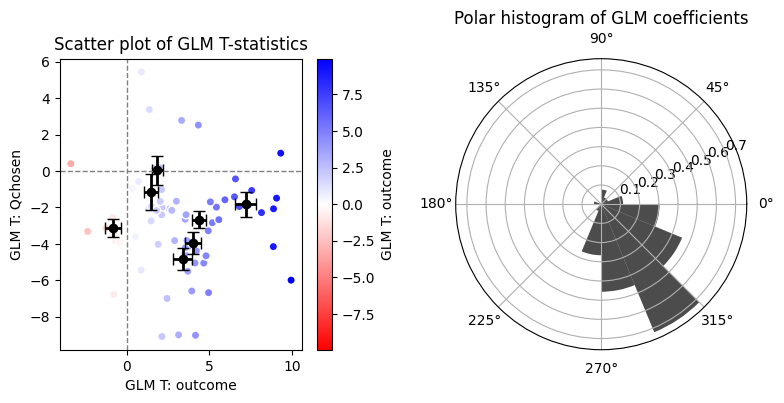

In [ ]:
from matplotlib.gridspec import GridSpec
# custom colormap red white blue
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_blue',
    ['red', 'white', 'blue']
)


# --- indices ---
regressors = list(results['regressors'])
outcome_ind = regressors.index('outcome')
q_ind = regressors.index('Qchosen')

# --- extract T-stats ---
T_outcome = results['tstats'][:, target_start_ind, outcome_ind]
T_q = results['tstats'][:, target_start_ind, q_ind]

# --- extract coefficients ---
coef_outcome = results['coefs'][:, target_start_ind, outcome_ind]
coef_q = results['coefs'][:, target_start_ind, q_ind]

# --- vectors ---
all_vec = np.column_stack((coef_outcome, coef_q))

# Cartesian → polar
theta = np.arctan2(all_vec[:, 1], all_vec[:, 0])   # y, x (standard convention)
rho = np.hypot(all_vec[:, 0], all_vec[:, 1])

# --- figure ---
fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig)

# ===== Scatter plot =====
ax_scatter = fig.add_subplot(gs[0, 0])
sc = ax_scatter.scatter(
    T_outcome,
    T_q,
    c=T_outcome,
    alpha=1,
    edgecolors=[1, 1, 1],
    cmap=custom_cmap,
    norm=plt.Normalize(vmin=min(-np.abs(T_outcome)), vmax=max(np.abs(T_outcome)))
)

# scatter plot mean T values for each animal's sessions and error bars as standard error
for ani_ind, ani in enumerate(ani_results['ani_list']):
    ani_inds = [i for i, x in enumerate(results['session_list']) if session_dirs(x)['aniID'] == ani]
    print(f'Animal {ani}: indices {len(ani_inds)}')
    ani_T_outcome = T_outcome[ani_inds]
    ani_T_q = T_q[ani_inds]
    ani_T_outcome_1_model = ani_results['tstats'][ani_ind, target_start_ind, ani_results['regressors'].index('outcome')]
    ani_T_q_1_model = ani_results['tstats'][ani_ind, target_start_ind, ani_results['regressors'].index('Qchosen')]
    ax_scatter.errorbar(
        np.mean(ani_T_outcome),
        np.mean(ani_T_q),
        xerr=np.std(ani_T_outcome) / np.sqrt(len(ani_T_outcome)),
        yerr=np.std(ani_T_q) / np.sqrt(len(ani_T_q)),
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=2,
        capsize=4,
        markersize=6
    )
    
ax_scatter.set_xlabel('GLM T: outcome')
ax_scatter.set_ylabel('GLM T: Qchosen')
ax_scatter.axhline(0, color='gray', linestyle='--', lw=1)
ax_scatter.axvline(0, color='gray', linestyle='--', lw=1)
ax_scatter.set_title('Scatter plot of GLM T-statistics')

plt.colorbar(sc, ax=ax_scatter, label='GLM T: outcome')

# ===== Polar histogram =====
edges = np.linspace(-np.pi, np.pi, 17)  # 16 bins

ax_polar = fig.add_subplot(gs[0, 1], polar=True)
ax_polar.hist(
    theta,
    bins=edges,
    color='k',
    alpha=0.7,
    density=True
)
ax_polar.set_title('Polar histogram of GLM coefficients')

plt.tight_layout()

if not os.path.exists(save_dir):
    os.makedirs(save_dir)
fig.savefig(os.path.join(save_dir, f'scatter_polar_histogram_start_{target_start}_from_{session_file_name.split(".pkl")[0]}.pdf'))
plt.show()


In [ ]:
ani_results['ani_list']

['669489',
 '669492',
 '672850',
 '699462',
 '699472',
 '701707',
 '749472',
 '749624',
 '754895',
 '754896',
 '754898']

Parsing session_id: behavior_669492_2023-06-24_17-28-24, aniID: 669492
Parsing session_id: behavior_669492_2023-06-26_19-14-31, aniID: 669492
Parsing session_id: behavior_669492_2023-06-29_18-28-17, aniID: 669492
Parsing session_id: behavior_669492_2023-06-30_15-51-45, aniID: 669492
Parsing session_id: behavior_669492_2023-07-01_19-25-23, aniID: 669492
Parsing session_id: behavior_669492_2023-07-02_16-02-53, aniID: 669492
Parsing session_id: behavior_669492_2023-07-03_15-55-33, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-05_18-51-39, aniID: 669492
Parsing session_id: behavior_669492_2023-07-06_16-39-19, aniID: 669492
Parsing session_id: behavior_669492_2023-07-07_17-52-04, aniID: 669492
Parsing session_id: behavior_669492_2023-07-08_19-35-55, aniID: 669492
Parsing session_id: behavior_669492_2023-07-10_17-03-12, aniID: 669492
Parsing session_id: behavior_669492_2023-07-11_19-01-10, aniID: 669492
Parsin

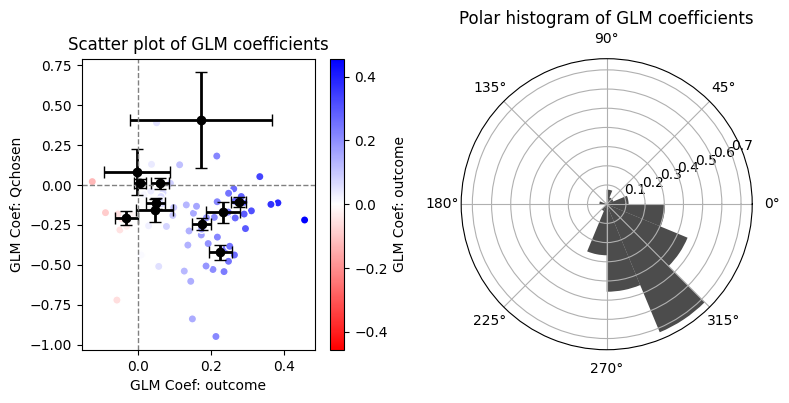

In [ ]:
# plot another version of coeffs

custom_cmap = LinearSegmentedColormap.from_list(
    'red_white_blue',
    ['red', 'white', 'blue']
)


# --- indices ---
regressors = list(results['regressors'])
outcome_ind = regressors.index('outcome')
q_ind = regressors.index('Qchosen')

# --- extract coefficients ---
coef_outcome = results['coefs'][:, target_start_ind, outcome_ind]
coef_q = results['coefs'][:, target_start_ind, q_ind]

# --- vectors ---
all_vec = np.column_stack((coef_outcome, coef_q))

# Cartesian → polar
theta = np.arctan2(all_vec[:, 1], all_vec[:, 0])   # y, x (standard convention)
rho = np.hypot(all_vec[:, 0], all_vec[:, 1])

# --- figure ---
fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig)

# ===== Scatter plot =====
ax_scatter = fig.add_subplot(gs[0, 0])
sc = ax_scatter.scatter(
    coef_outcome,
    coef_q,
    c=coef_outcome,
    alpha=1,
    edgecolors=[1, 1, 1],
    cmap=custom_cmap,
    norm=plt.Normalize(vmin=min(-np.abs(coef_outcome)), vmax=max(np.abs(coef_outcome)))
)

# scatter plot each animal's coef and error bars as confidence interval of the coefficient in 1 model with all sessions from the animal as input
for ani_ind, ani in enumerate(ani_results['ani_list']):
    ani_inds = [i for i, x in enumerate(results['session_list']) if session_dirs(x)['aniID'] == ani]
    ani_coef_outcome = coef_outcome[ani_inds]
    ani_coef_q = coef_q[ani_inds]
    ani_coef_outcome_1_model = ani_results['coefs'][ani_ind, target_start_ind, outcome_ind]
    ani_CI_outcome_1_model = ani_results['conf_int'][ani_ind, target_start_ind, :, outcome_ind]
    ani_coef_q_1_model = ani_results['coefs'][ani_ind, target_start_ind, q_ind]
    ani_CI_q_1_model = ani_results['conf_int'][ani_ind, target_start_ind, :, q_ind]
    ax_scatter.errorbar(
        np.mean(ani_coef_outcome_1_model),
        np.mean(ani_coef_q_1_model),
        xerr= (ani_CI_outcome_1_model[1] - ani_CI_outcome_1_model[0]) / 2,
        yerr= (ani_CI_q_1_model[1] - ani_CI_q_1_model[0]) / 2,
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=2,
        capsize=4,
        markersize=6
    )
    
ax_scatter.set_xlabel('GLM Coef: outcome')
ax_scatter.set_ylabel('GLM Coef: Qchosen')
ax_scatter.axhline(0, color='gray', linestyle='--', lw=1)
ax_scatter.axvline(0, color='gray', linestyle='--', lw=1)
ax_scatter.set_title('Scatter plot of GLM coefficients')
plt.colorbar(sc, ax=ax_scatter, label='GLM Coef: outcome')

# ===== Polar histogram =====
edges = np.linspace(-np.pi, np.pi, 17)  # 16 bins

ax_polar = fig.add_subplot(gs[0, 1], polar=True)
ax_polar.hist(
    theta,
    bins=edges,
    color='k',
    alpha=0.7,
    density=True
)
ax_polar.set_title('Polar histogram of GLM coefficients')

plt.tight_layout()
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
fig.savefig(os.path.join(save_dir, f'scatter_coeff_polar_histogram_start_{target_start}_from_{session_file_name.split(".pkl")[0]}.pdf'))
plt.show()


In [ ]:
ani_results['conf_int'][ani_ind, target_start_ind, :, q_ind]

array([-0.23277677, -0.08519818])

In [ ]:
# hit_file_name = 'population_GLM_mPFC_G_tri-exp_mc_respondTime_win2000_thresg0.5_formula_1_hit.pkl'
# hit_file_name = 'population_GLM_mPFC_G_tri-exp_mc_CSon_win1000_thresg0.5_formula_1_hit_outcome.pkl'
hit_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_goCue_start_time_win2_thresh0.5_formula_1_hit_iso.pkl'
switch_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_goCue_start_time_win0.75_thresh0.5_formula_1_svs_outcome_iso.pkl'
# hit_response_file_name = 'population_GLM_session-wise_PL_G_tri-exp_mc_goCue_start_time_win500_thresh0.5_formula_1_hit_outcome.pkl'


hit_ani_file_name = 'population_GLM_animal-wise_PL_G_tri-exp_mc_goCue_start_time_win2_thresh0.5_formula_1_hit_iso.pkl'
# hit_ani_file_name = 'population_GLM_ani_mPFC_G_tri-exp_mc_CSon_win2000_thresg0.5_formula_1_hit.pkl'
# hit_ani_response_file_name = 'population_GLM_ani_mPFC_G_tri-exp_mc_CSon_win500_thresg0.5_formula_1_hit_outcome.pkl'
switch_ani_file_name = 'population_GLM_animal-wise_PL_G_tri-exp_mc_goCue_start_time_win0.75_thresh0.5_formula_1_svs_outcome_iso.pkl'

with open(os.path.join(save_dir, hit_file_name), 'rb') as f:
    hit_params_dict = pickle.load(f)
    hit_results = pickle.load(f)
with open(os.path.join(save_dir, switch_file_name), 'rb') as f:
    switch_params_dict = pickle.load(f)
    switch_results = pickle.load(f)
# with open(os.path.join(save_dir, hit_response_file_name), 'rb') as f:
#     hit_response_params_dict = pickle.load(f)
#     hit_response_results = pickle.load(f)


with open(os.path.join(save_dir, hit_ani_file_name), 'rb') as f:
    hit_ani_params_dict = pickle.load(f)
    hit_ani_results = pickle.load(f)
# with open(os.path.join(save_dir, hit_ani_response_file_name), 'rb') as f:
#     hit_ani_response_params_dict = pickle.load(f)
#     hit_ani_response_results = pickle.load(f)
with open(os.path.join(save_dir, switch_ani_file_name), 'rb') as f:
    switch_ani_params_dict = pickle.load(f)
    switch_ani_results = pickle.load(f)
plt.close('all')
    

In [ ]:
hit_bl_bin_ind = np.argmax(np.where(hit_results['time_bins'] + 0.5*hit_params_dict['window_size']<=0)[0])
# hit_response_bin_ind = np.where(hit_response_results['time_bins']>=0)[0][0] 
switch_bin_ind = np.where(switch_results['time_bins'] - 0.5*switch_params_dict['window_size'] > 0)[0][0]

hit_bl_bin_ind_ani = np.argmax(np.where(hit_ani_results['time_bins'] + hit_ani_params_dict['window_size']<=0)[0])
# hit_response_bin_ind_ani = np.where(hit_ani_response_results['time_bins']>=0)[0][0]
switch_bin_ind_ani = np.where(switch_ani_results['time_bins'] > 0)[0][0]

In [ ]:
pd.DataFrame({
    'ani': switch_ani_results['ani_list'],
    'coef_svs': switch_ani_results['coefs'][:, switch_bin_ind_ani, switch_ani_results['regressors'].index('svs')]
})

,ani,coef_svs
0,669489,0.137884
1,669492,0.040512
2,672850,-0.139254
3,699462,0.169012
4,699472,0.027107
5,701707,-0.124886
6,749472,0.000144
7,749624,0.016595
8,754895,-0.091369
9,754896,0.089096


In [ ]:
# align sessions
hit_session = hit_results['session_list']
# hit_response_session = hit_response_results['session_list']
switch_session = switch_results['session_list']
common_sessions = list(set(hit_session) & set(switch_session))
hit_session_inds = [hit_session.index(session) for session in common_sessions]
switch_session_inds = [switch_session.index(session) for session in common_sessions]
# hit_response_session_inds = [hit_response_session.index(session) for session in common_sessions]
# extract tstats for regressor of interest

# align animals
hit_ani_list = hit_ani_results['ani_list']
switch_ani_list = switch_ani_results['ani_list']
# hit_ani_response_list = hit_ani_response_results['ani_list']
common_ani = list(set(hit_ani_list) & set(switch_ani_list))
hit_ani_inds = [hit_ani_list.index(ani) for ani in common_ani]
switch_ani_inds = [switch_ani_list.index(ani) for ani in common_ani]

Parsing session_id: behavior_669492_2023-06-24_17-28-24, aniID: 669492
Parsing session_id: behavior_669492_2023-06-26_19-14-31, aniID: 669492
Parsing session_id: behavior_669492_2023-06-29_18-28-17, aniID: 669492
Parsing session_id: behavior_669492_2023-06-30_15-51-45, aniID: 669492
Parsing session_id: behavior_669492_2023-07-01_19-25-23, aniID: 669492
Parsing session_id: behavior_669492_2023-07-02_16-02-53, aniID: 669492
Parsing session_id: behavior_669492_2023-07-03_15-55-33, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-05_18-51-39, aniID: 669492
Parsing session_id: behavior_669492_2023-07-06_16-39-19, aniID: 669492
Parsing session_id: behavior_669492_2023-07-07_17-52-04, aniID: 669492
Parsing session_id: behavior_669492_2023-07-08_19-35-55, aniID: 669492
Parsing session_id: behavior_669492_2023-07-10_17-03-12, aniID: 669492
Parsing session_id: behavior_669492_2023-07-11_19-01-10, aniID: 669492
Parsin

/opt/conda/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/conda/lib/python3.10/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_699462_2024-01-12_11-40-23, aniID: 699462
Parsing session_id: behavior_699462_2024-01-13_15-11-33, aniID: 699462
Parsing session_id: behavior_699462_2024-01-14_15-41-48, aniID: 699462
Parsing session_id: behavior_699462_2024-01-16_12-10-12, aniID: 699462
Parsing session_id: behavior_699462_2024-01-17_10-36-54, aniID: 699462
Parsing session_id: behavior_699472_2023-12-21_11-59-56, aniID: 699472
Parsing session_id: behavior_699472_2024-01-02_13-53-59, aniID: 699472
Parsing session_id: behavior_699472_2024-01-03_15-13-23, aniID: 699472
Parsing session_id: behavior_699472_2024-01-04_15-04-09, aniID: 699472
Parsing session_id: behavior_699472_2024-01-05_12-52-27, aniID: 699472
Parsing session_id: behavior_699472_2024-01-06_14-52-56, aniID: 699472
Parsing session_id: behavior_699472_2024-01-11_13-08-25, aniID: 699472
Parsing session_id: behavior_699472_2024-01-13_16-41-33, aniID: 699472
Parsin

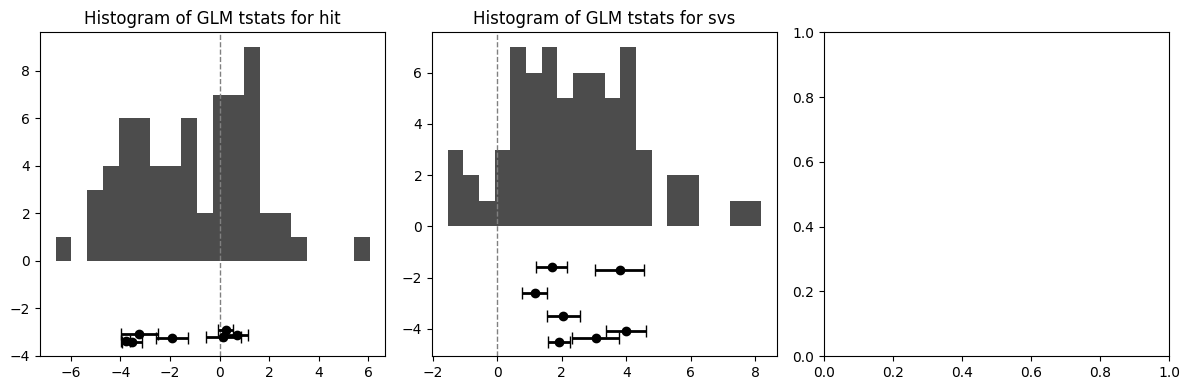

In [ ]:
#plot histogram of x_values and y_values
T_or_coeff = 'tstats'
x_val = 'hit'
y_val = 'svs'
hit_period = 'resp'
x_values = hit_results[T_or_coeff][:, hit_bl_bin_ind, hit_results['regressors'].index(x_val)]
y_values = switch_results[T_or_coeff][:, switch_bin_ind, switch_results['regressors'].index(y_val)]

fig_hist = plt.figure(figsize=(12, 4))
gs_hist = GridSpec(1, 3, figure=fig_hist)
ax_hist_x = fig_hist.add_subplot(gs_hist[0, 0])
ax_hist_y = fig_hist.add_subplot(gs_hist[0, 1])
ax_hist_z = fig_hist.add_subplot(gs_hist[0, 2])

ax_hist_x.hist(x_values, bins=20, color='k', alpha=0.7)
ax_hist_x.set_title(f'Histogram of GLM {T_or_coeff} for {x_val}')
ax_hist_x.axvline(0, color='gray', linestyle='--', lw=1)
# add animal-wise mean and standard error as vertical line and shaded area
for ani_ind, ani in enumerate(np.array(hit_ani_results['ani_list'])):
    ani_inds = [i for i, x in enumerate(hit_results['session_list']) if session_dirs(x)['aniID'] == ani]
    ani_x_values = x_values[ani_inds]
    y_value = 2*(np.random.rand()-0.5) - 3
    ax_hist_x.errorbar(
        np.mean(ani_x_values),
        y_value,
        xerr=np.std(ani_x_values) / np.sqrt(len(ani_x_values)),
        fmt='o',    
        color='k',
        ecolor='k',
        elinewidth=2,
        capsize=4,
        markersize=6
    )

ax_hist_y.hist(y_values, bins=20, color='k', alpha=0.7)
ax_hist_y.set_title(f'Histogram of GLM {T_or_coeff} for {y_val}')
ax_hist_y.axvline(0, color='gray', linestyle='--', lw=1)
for ani_ind, ani in enumerate(np.array(switch_ani_results['ani_list'])):
    ani_inds = [i for i, x in enumerate(switch_results['session_list']) if session_dirs(x)['aniID'] == ani]
    ani_y_values = y_values[ani_inds]
    y_value = 3*(np.random.rand()-0.5) - 3
    ax_hist_y.errorbar(
        np.mean(ani_y_values),
        y_value,
        xerr=np.std(ani_y_values) / np.sqrt(len(ani_y_values)),
        fmt='o',    
        color='k',
        ecolor='k',
        elinewidth=2,
        capsize=4,
        markersize=6
    )

# ax_hist_z.hist(x_values_response, bins=20, color='k', alpha=0.7)
# ax_hist_z.set_title(f'Histogram of GLM {T_or_coeff} for {x_val} (response)')    
# ax_hist_z.axvline(0, color='gray', linestyle='--', lw=1)    

# for ani_ind, ani in enumerate(np.array(hit_ani_response_results['ani_list'])):
#     ani_inds = [i for i, x in enumerate(hit_response_results['session_list']) if parse_session_string(x)['aniName'] == ani]
#     ani_x_values_response = x_values_response[ani_inds]
#     y_value = 2*(np.random.rand()-0.5) - 3
#     ax_hist_z.errorbar(
#         np.mean(ani_x_values_response),
#         y_value,
#         xerr=np.std(ani_x_values_response) / np.sqrt(len(ani_x_values_response)),
#         fmt='o',    
#         color='k',
#         ecolor='k',
#         elinewidth=2,
#         capsize=4,
#         markersize=6
#     )
plt.tight_layout()  
fig_hist.savefig(os.path.join(save_dir, f'histogram_hit_svs.svg'))